In [6]:
!pip install -q sentence-transformers
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

In [7]:
import pandas as pd
df = pd.read_csv('cleaned_dataset_2.csv')
print("✅ Data loaded:", df.shape)
df.head(3)


✅ Data loaded: (226, 25)


,item_id,title,description,tags,category,location,state,min price (RM),max price (RM),operating hours,...,contact,more_info,opening_time,closing_time,price_type,clean_description,clean_tags,clean_category,clean_features,weighted_features
0,1,Ilham Ceramic Studio,"Ilham Seramik Studio showcases ceramic-making,...","ceramic, pottery, craft",Arts & Crafts,"Ilham Ceramic Studio, Kampung Bendang Baru, 07...",Kedah,8.0,518.0,9:00 AM - 5:00 PM,...,013-599 4022,https://www.instagram.com/ilham_ceramic/?hl=en,09:00:00,17:00:00,Paid,ilham seramik studio showcase ceramicmaking cl...,ceramic pottery craft,art craft,ilham seramik studio showcase ceramicmaking cl...,Ilham Ceramic Studio Ilham Seramik Studio show...
1,2,Maklang Cafe By Ilham Ceramic Studio,Maklang Cafe by Ilham Ceramic offers cultural ...,"food, culinary, culture",Food & Culinary,"Ilham Ceramic Studio, Kampung Bendang Baru, 07...",Kedah,0.5,15.0,8:00 AM - 6:00 PM,...,013-599 4022,https://naturallylangkawi.my/portfolio/ilham-s...,08:00:00,18:00:00,Paid,maklang cafe ilham ceramic offer cultural cuis...,food culinary culture,food culinary,maklang cafe ilham ceramic offer cultural cuis...,Maklang Cafe By Ilham Ceramic Studio Maklang C...
2,3,Perencah Mee Bandung Mak Pon,Perencah Mee Bandung Mak Pon offers varieties ...,"food, paste, culinary",Food & Culinary,"1, 2 & 3, Jalan Lembah Padang, Taman Lembah Pa...",Johor,12.0,30.0,10:00 AM - 7:00 PM,...,012-262 0044,https://shopee.com.my/Pes-Mee-Bandung-Muar-Mi-...,10:00:00,19:00:00,Paid,perencah mee bandung mak pon offer variety pas...,food paste culinary,food culinary,perencah mee bandung mak pon offer variety pas...,Perencah Mee Bandung Mak Pon Perencah Mee Band...


In [10]:
df['semantic_features'] = (
    df['clean_description'] + ' ' +
    df['clean_tags'] + ' ' +
    df['clean_category']
)


In [12]:
# load pretrained sbert model
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

C:\Users\Asus\anaconda3\envs\LabSem5\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Asus\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [14]:
embeddings = model.encode(df['semantic_features'], show_progress_bar=True)
print("Embeddings shape:", embeddings.shape)


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

Embeddings shape: (226, 384)


In [16]:
cosine_sim = cosine_similarity(embeddings)
print("Cosine similarity matrix shape:", cosine_sim.shape)


Cosine similarity matrix shape: (226, 226)


In [18]:
def get_semantic_recommendations(item_name, df, cosine_sim, top_n=5):
    idx = df.index[df['title'].str.lower() == item_name.lower()].tolist()
    if not idx:
        print("Item not found.")
        return
    idx = idx[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    sim_indices = [i[0] for i in sim_scores]
    results = df[['title', 'category', 'state']].iloc[sim_indices]
    results['similarity'] = [i[1] for i in sim_scores]
    return results


In [64]:
get_semantic_recommendations("Natural Batik Village", df, cosine_sim)

,title,category,state,similarity
31,Mybatik Art Gallery,Arts & Crafts,Selangor,0.799180
30,Cwoks Batik Workshop,Arts & Crafts,Kuala Lumpur,0.790499
184,Batik House My,Arts & Crafts,Selangor,0.747657
183,Pakmud Batik,Arts & Crafts,Selangor,0.737236
34,Nordin Batik Sdn. Bhd,Arts & Crafts,Kelantan,0.732637


In [68]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

# Show top 5 semantic recommendations
def show_semantic_recommendations(item_index, cosine_sim, df, top_n=5):
    item_name = df.iloc[item_index]['title']
    print(f"\n🎯 Recommendations for: {item_name}\n")

    sim_scores = list(enumerate(cosine_sim[item_index]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:top_n+1]

    for i, score in sim_scores:
        print(f"{df.iloc[i]['title']} — {df.iloc[i]['category']} — {df.iloc[i]['state']} — similarity: {score:.3f}")

# Example: check for “Ilham Ceramic Studio”
target_index = df[df['title'].str.contains('Natural Batik Village', case=False, na=False)].index[0]
show_semantic_recommendations(target_index, cosine_sim, df)



🎯 Recommendations for: Natural Batik Village

Mybatik Art Gallery — Arts & Crafts — Selangor — similarity: 0.799
Cwoks Batik Workshop — Arts & Crafts — Kuala Lumpur — similarity: 0.790
Batik House My — Arts & Crafts — Selangor — similarity: 0.748
Pakmud Batik — Arts & Crafts — Selangor — similarity: 0.737
Nordin Batik Sdn. Bhd — Arts & Crafts — Kelantan — similarity: 0.733


C:\Users\Asus\AppData\Local\Temp\ipykernel_17996\3166193751.py:40: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) Arial.

C:\Users\Asus\anaconda3\envs\LabSem5\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128293 (\N{FIRE}) missing from font(s) Arial.



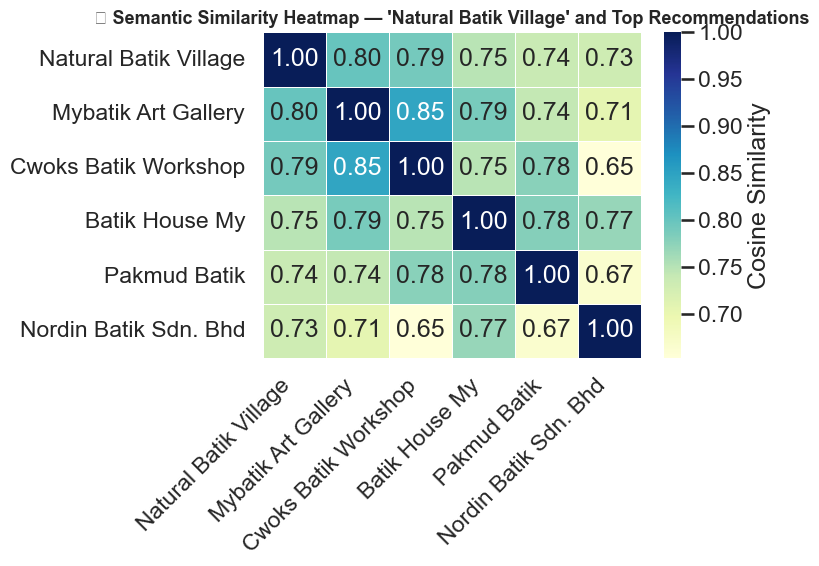

In [70]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 🎯 Choose a sample attraction (you can change this name)
target_item = "Natural Batik Village"

# Find index
target_idx = df[df['title'].str.contains(target_item, case=False, na=False)].index[0]

# Get similarity scores
sim_scores = list(enumerate(cosine_sim[target_idx]))
sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[0:6]  # target + top 5
sim_indices = [i[0] for i in sim_scores]

# Create subset dataframe
subset = df.iloc[sim_indices].copy()
subset['similarity_to_target'] = [i[1] for i in sim_scores]

# Create similarity matrix
heatmap_matrix = cosine_similarity(embeddings[sim_indices])

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_matrix,
    annot=True,
    cmap="YlGnBu",
    xticklabels=subset['title'].str.wrap(25),
    yticklabels=subset['title'].str.wrap(25),
    fmt=".2f",
    cbar_kws={'label': 'Cosine Similarity'},
    linewidths=0.5
)

plt.title(f"🔥 Semantic Similarity Heatmap — '{target_item}' and Top Recommendations", fontsize=13, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [72]:
#Visualization
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Reduce embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(embeddings)

# Add coordinates to DataFrame
df['x'] = embeddings_2d[:, 0]
df['y'] = embeddings_2d[:, 1]

print("✅ 2D embedding shape:", embeddings_2d.shape)

C:\Users\Asus\anaconda3\envs\LabSem5\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.



✅ 2D embedding shape: (226, 2)


C:\Users\Asus\anaconda3\envs\LabSem5\Lib\site-packages\sklearn\manifold\_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.

C:\Users\Asus\AppData\Local\Temp\ipykernel_17996\855791457.py:49: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Asus\AppData\Local\Temp\ipykernel_17996\855791457.py:49: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

C:\Users\Asus\AppData\Local\Temp\ipykernel_17996\855791457.py:49: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consis

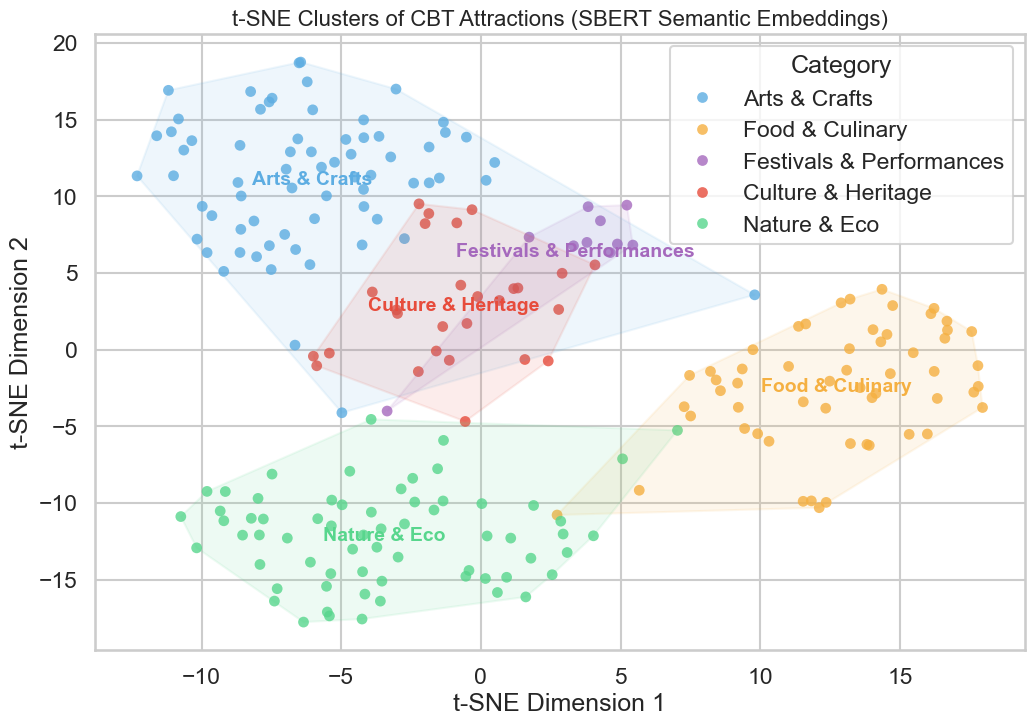

In [74]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE

# Run t-SNE again (if not done)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=2000)
tsne_embeddings = tsne.fit_transform(embeddings)

# Add results to DataFrame
df['tsne-2d-one'] = tsne_embeddings[:,0]
df['tsne-2d-two'] = tsne_embeddings[:,1]

# Define custom color palette for clusters
palette = {
    'Arts & Crafts': '#5DADE2',
    'Food & Culinary': '#F5B041',
    'Festivals & Performances': '#A569BD',
    'Culture & Heritage': '#E74C3C',
    'Nature & Eco': '#58D68D'
}

plt.figure(figsize=(12, 8))
sns.set(style="whitegrid", context="talk")

# Plot scatter points
sns.scatterplot(
    x='tsne-2d-one', y='tsne-2d-two',
    hue='category',
    palette=palette,
    data=df,
    s=60, alpha=0.8, edgecolor='none'
)

# Add soft color zones by plotting filled convex hulls
from scipy.spatial import ConvexHull
for category, color in palette.items():
    subset = df[df['category'] == category][['tsne-2d-one', 'tsne-2d-two']]
    if len(subset) > 2:  # hull needs at least 3 points
        hull = ConvexHull(subset)
        plt.fill(
            subset.iloc[hull.vertices, 0],
            subset.iloc[hull.vertices, 1],
            color=color, alpha=0.1
        )
        # Label the cluster
        center = subset.mean()
        plt.text(center[0], center[1], category,
                 fontsize=14, weight='bold',
                 color=color, ha='center', va='center')

plt.title("t-SNE Clusters of CBT Attractions (SBERT Semantic Embeddings)", fontsize=16)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title="Category", loc="upper right", frameon=True)
plt.show()


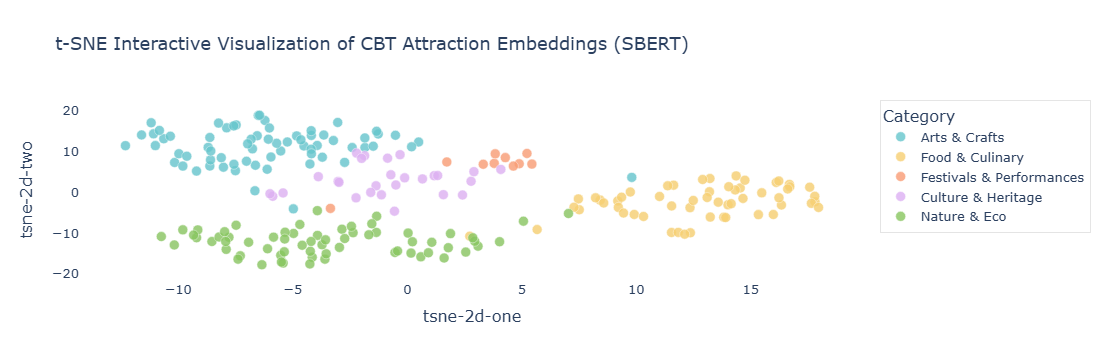

In [62]:
import plotly.express as px

# Assuming your DataFrame is called `df` and includes:
# 'tsne-2d-one', 'tsne-2d-two', 'category', 'title', 'state'

fig = px.scatter(
    df,
    x='tsne-2d-one',
    y='tsne-2d-two',
    color='category',
    hover_data={'title': True, 'category': True, 'state': True},
    title='t-SNE Interactive Visualization of CBT Attraction Embeddings (SBERT)',
    color_discrete_sequence=px.colors.qualitative.Pastel
)

# Aesthetic settings
fig.update_layout(
    plot_bgcolor='rgba(0,0,0,0)',
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(size=13),
    legend=dict(
        title='Category',
        bgcolor='rgba(255,255,255,0.8)',
        bordercolor='rgba(0,0,0,0.1)',
        borderwidth=1
    )
)

# Improve point size and transparency
fig.update_traces(marker=dict(size=10, opacity=0.8, line=dict(width=0.5, color='white')))

fig.show()
